# Volleyball - Monte Carlo


In [10]:
import tkinter as tk
import threading
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [11]:
# Environment and UI constants (same as volleyball app)
ROWS, COLS = 5, 9
CELL = 80
START = (2, 1)
OUTCOME = (2, 7)
ACTION_COL = 4
ACTION_ROWS = { 'pass': 0, 'emergency': 1, 'dump': 2, 'quick': 3, 'high': 4 }
MOVES = ['right','down','left','up']
ROW_OPTIONS = ['front','back']
PASS_OPTIONS = ['good','bad']
BLOCK_OPTIONS = ['blockers','noblockers']

def is_action_tile(r,c):
    return c == ACTION_COL and r in ACTION_ROWS.values()

def action_from_rc(r,c):
    if c != ACTION_COL: return None
    for name, rr in ACTION_ROWS.items():
        if rr == r: return name
    return None

def legal_action(row, pass_quality, action):
    if action == 'dump' and row == 'back':
        return False
    if pass_quality == 'good':
        return action in {'high','quick','dump','pass'} if row=='front' else action in {'high','quick','pass'}
    else:
        return action in {'emergency','dump','pass'} if row=='front' else action in {'emergency','pass'}

def success_probability(row, pass_quality, blockers, action):
    probs = { 'high':0.5, 'quick':0.5, 'dump':0.3, 'emergency':0.4, 'pass':0.0 }
    if pass_quality == 'bad':
        if row == 'back':
            if blockers == 'blockers':
                probs['emergency'] = 0.25
            else:
                probs['emergency'] = 0.55
        else:
            if blockers == 'blockers':
                probs['emergency'] = 0.6; probs['dump'] = 0.25
            else:
                probs['dump'] = 0.8; probs['emergency'] = 0.5
    else:
        if blockers == 'blockers':
            probs['quick'] = 0.65; probs['high']  = 0.65
            if row=='front': probs['dump'] = 0.4
        else:
            probs['quick'] = 0.85; probs['high']  = 0.85
            if row=='front': probs['dump'] = 0.8
    return probs.get(action, 0.0)

STEP_PENALTY = -0.01
ILLEGAL_PENALTY = -1.0
SECOND_DECISION_PENALTY = -1.0
REVISIT_SAME_DECISION_PENALTY = -0.5
NO_ACTION_AT_GOAL = -0.5
PASS_REWARD = -0.2
EMERGENCY_WHEN_GOOD = -0.3

ACTIONS_LIST = [None, 'pass','emergency','dump','quick','high']

def move_pos(r,c,move):
    if move=='up':    return max(0,r-1), c
    if move=='down':  return min(ROWS-1,r+1), c
    if move=='left':  return r, max(0,c-1)
    if move=='right': return r, min(COLS-1,c+1)
    return r,c

def transitions(s, a):
    r,c,row,pq,bl,chosen = s
    nr,nc = move_pos(r,c,a)
    reward = STEP_PENALTY
    done = False
    next_chosen = chosen
    if is_action_tile(nr,nc):
        act = action_from_rc(nr,nc)
        if chosen is None:
            if not legal_action(row,pq,act):
                reward += ILLEGAL_PENALTY; done = True
            else:
                next_chosen = act
        else:
            if act == chosen: reward += REVISIT_SAME_DECISION_PENALTY
            else: reward += SECOND_DECISION_PENALTY
    if (nr,nc) == OUTCOME and not done:
        if next_chosen is None: reward += NO_ACTION_AT_GOAL
        elif next_chosen == 'pass': reward += PASS_REWARD
        elif next_chosen == 'emergency' and pq=='good': reward += EMERGENCY_WHEN_GOOD
        else:
            p = success_probability(row,pq,bl,next_chosen); reward += 2*p - 1
        done = True
    ns = (nr,nc,row,pq,bl,next_chosen)
    return [(ns, 1.0, reward, done)]

def greedy_action_fallback(s):
    r, c, row, pq, bl, chosen = s
    target_c = ACTION_COL if chosen is None else OUTCOME[1]
    if c < target_c: return 'right'
    if c > target_c: return 'left'
    if chosen is None:
        action_rows = list(ACTION_ROWS.values())
        target_r = min(action_rows, key=lambda rr: abs(rr - r))
    else:
        target_r = OUTCOME[0]
    if r < target_r: return 'down'
    if r > target_r: return 'up'
    return 'right'

def reset_random_conditions():
    return random.choice(ROW_OPTIONS), random.choice(PASS_OPTIONS), random.choice(BLOCK_OPTIONS)

def step_mc(s, a, sample_terminal=True):
    ns, p, r, done = transitions(s, a)[0]
    if done and (ns[0], ns[1]) == OUTCOME:
        row, pq, bl, chosen = ns[2], ns[3], ns[4], ns[5]
        if sample_terminal and chosen not in (None, 'pass'):
            r = 1.0 if random.random() < success_probability(row, pq, bl, chosen) else -1.0
    return ns, r, done


In [ ]:
# Monte Carlo utilities (Prediction uses random + exploring starts, identical UI)
def random_policy(_s):
    return random.choice(MOVES)

def generate_episode(policy_fn, start_conditions=None, max_steps=200, sample_terminal=True, exploring_starts=False):
    row, pq, bl = start_conditions if start_conditions is not None else reset_random_conditions()
    if exploring_starts:
        sr = random.randrange(ROWS); sc = random.randrange(COLS)
        s = (sr, sc, row, pq, bl, None)
    else:
        s = (START[0], START[1], row, pq, bl, None)
    states, actions, rewards = [], [], []
    steps, done = 0, False
    while not done and steps < max_steps:
        a = policy_fn(s)
        ns, r, done = step_mc(s, a, sample_terminal=sample_terminal)
        states.append(s); actions.append(a); rewards.append(r)
        s = ns; steps += 1
    return states, actions, rewards

def epsilon_greedy_from_Q(Q, eps):
    def pi(s):
        if not Q[s]:
            return random.choice(MOVES) if random.random() < eps else greedy_action_fallback(s)
        best_a = max(MOVES, key=lambda a: Q[s].get(a, 0.0))
        if random.random() < eps: return random.choice(MOVES)
        return best_a
    return pi

def mc_prediction(first_visit=True, episodes=5000, gamma=0.95, sample_terminal=True, start_conditions=None, animate_cb=None):
    V = defaultdict(float); N = defaultdict(int)
    for ep in range(1, episodes+1):
        #! Builds random sequences
        S, A, R = generate_episode(random_policy, start_conditions, sample_terminal=sample_terminal, exploring_starts=True)
        G = 0.0; returns = [0.0]*len(R)
        for t in reversed(range(len(R))):
            G = R[t] + gamma * G
            returns[t] = G
        if first_visit:
            seen = set()
            for t, s in enumerate(S):
                if s in seen: continue
                seen.add(s); V[s] += returns[t]; N[s] += 1
        else:
            # Every-Visit: update on all occurrences in the episode
            for t, s in enumerate(S):
                V[s] += returns[t]; N[s] += 1
        if animate_cb and ep % 50 == 0: animate_cb(ep)
    for s in V: V[s] /= max(1, N[s])
    return V

def mc_control(first_visit=True, episodes=20000, gamma=0.95, eps_start=0.2, eps_end=0.01, sample_terminal=True, start_conditions=None, animate_cb=None):
    Q = defaultdict(lambda: defaultdict(float)); N = defaultdict(lambda: defaultdict(int))
    def current_pi_builder(eps): return epsilon_greedy_from_Q(Q, eps)
    eps = eps_start; pi = current_pi_builder(eps)
    for ep in range(1, episodes+1):
        eps = eps_end + (eps_start - eps_end) * max(0, (episodes - ep)) / episodes
        pi = current_pi_builder(eps)
        S, A, R = generate_episode(pi, start_conditions, sample_terminal=sample_terminal)
        G = 0.0; returns = [0.0]*len(R)
        for t in reversed(range(len(R))):
            G = R[t] + gamma * G
            returns[t] = G
        if first_visit:
            seen = set()
            for t, (s,a) in enumerate(zip(S,A)):
                if (s,a) in seen: continue
                seen.add((s,a))
                N[s][a] += 1
                Q[s][a] += (returns[t] - Q[s][a]) / N[s][a]
        else:
            # Every-Visit: update all (s,a) occurrences
            for t, (s,a) in enumerate(zip(S,A)):
                N[s][a] += 1
                Q[s][a] += (returns[t] - Q[s][a]) / N[s][a]
        if animate_cb and ep % 50 == 0: animate_cb(ep)
    return Q

def V_from_Q(Q):
    V = defaultdict(float)
    for s in Q.keys(): V[s] = max((Q[s].get(a,0.0) for a in MOVES), default=0.0)
    return V

def greedy_from_Q(Q):
    def pi(s):
        if not Q[s]: return greedy_action_fallback(s)
        return max(MOVES, key=lambda a: Q[s].get(a,0.0))
    return pi


In [13]:
# Plotting (same style)
def grid_values_for(V, row, pq, bl, chosen=None):
    M = np.zeros((ROWS, COLS), dtype=float)
    for r in range(ROWS):
        for c in range(COLS):
            s = (r, c, row, pq, bl, chosen)
            M[r, c] = V.get(s, 0.0)
    return M

def plot_state_values_all_from_V(V):
    combos = [
        ('front','good','blockers'), ('front','good','noblockers'),
        ('front','bad','blockers'),  ('front','bad','noblockers'),
        ('back','good','blockers'),  ('back','good','noblockers'),
        ('back','bad','blockers'),   ('back','bad','noblockers'),
    ]
    mats = [grid_values_for(V, row, pq, bl, chosen=None) for (row, pq, bl) in combos]
    all_vals = np.concatenate([m.flatten() for m in mats])
    vmin, vmax = float(np.min(all_vals)), float(np.max(all_vals))
    if vmin == vmax: vmin, vmax = vmin-1e-6, vmax+1e-6
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
    axes = axes.ravel()
    for ax, (row, pq, bl), M in zip(axes, combos, mats):
        im = ax.imshow(M, cmap='coolwarm', vmin=vmin, vmax=vmax, origin='upper', interpolation='nearest')
        ax.set_title(f'{row}, {pq}, {bl}')
        ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
        ax.scatter([START[1]], [START[0]], s=80, c='lime', marker='s', edgecolors='k')
        ax.scatter([OUTCOME[1]], [OUTCOME[0]], s=80, c='yellow', marker='*', edgecolors='k')
    cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9); cbar.set_label('V(s)')
    plt.show()


In [14]:
# App (UI preserved); First-Visit or Every-Visit driven by first_visit flag
class MCBaseApp:
    def __init__(self, mode_name, first_visit=True, control=False):
        self.mode_name = mode_name; self.first_visit = first_visit; self.control = control
        self.root = tk.Tk(); self.root.title(f'Monte Carlo — {mode_name}')
        self.canvas = tk.Canvas(self.root, width=COLS*CELL, height=ROWS*CELL, bg='white'); self.canvas.pack()
        self.status = tk.Label(self.root, text='Ready', anchor='w'); self.status.pack(fill='x')
        self.cond_label = tk.Label(self.root, text='Conditions: —', anchor='w'); self.cond_label.pack(fill='x')
        ctl = tk.Frame(self.root); ctl.pack(fill='x')
        self.train_btn = tk.Button(ctl, text='Train', command=self.start_training, bg='#2e7d32', fg='white'); self.train_btn.pack(side='left', padx=5)
        self.test_btn  = tk.Button(ctl, text='Test Policy', command=self.start_testing, bg='#1565c0', fg='white'); self.test_btn.pack(side='left', padx=5)
        self.demo_btn  = tk.Button(ctl, text='Run Demo', command=self.start_demo, bg='#ef6c00', fg='white'); self.demo_btn.pack(side='left', padx=5)
        self.stop_btn  = tk.Button(ctl, text='Stop Demo', command=self.stop_demo, bg='#b71c1c', fg='white'); self.stop_btn.pack(side='left', padx=5)
        tk.Label(ctl, text='Speed (ms/step)').pack(side='left', padx=(20,4))
        self.speed = tk.Scale(ctl, from_=0, to=800, orient='horizontal'); self.speed.set(200); self.speed.pack(side='left')
        tk.Label(ctl, text='Episodes').pack(side='left', padx=(20,4))
        self.num_episodes = tk.IntVar(value=300)
        self.ep_entry = tk.Spinbox(ctl, from_=1, to=10000, textvariable=self.num_episodes, width=6); self.ep_entry.pack(side='left')
        self.graph_btn = tk.Button(ctl, text='Compute Graphs', command=self.show_graphs, bg='#6a1b9a', fg='white'); self.graph_btn.pack(side='left', padx=5)
        self.draw_board(); self.agent_token = None
        self.V = defaultdict(float); self.Q = None
        self.episode_rewards = []; self.cumulative_rewards = []
        self.running_demo=False; self.demo_state=None; self.demo_steps=0

    def draw_board(self):
        self.canvas.delete('all')
        for r in range(ROWS):
            for c in range(COLS):
                x1,y1 = c*CELL, r*CELL; x2,y2 = x1+CELL, y1+CELL
                fill='white'
                if (r,c)==START: fill='#c8e6c9'
                if (r,c)==OUTCOME: fill='#ffcdd2'
                if is_action_tile(r,c): fill='#fff9c4'
                self.canvas.create_rectangle(x1,y1,x2,y2, fill=fill, outline='black')
                if is_action_tile(r,c):
                    name=action_from_rc(r,c)
                    self.canvas.create_text(x1+CELL/2, y1+CELL/2, text=name.title(), font=('Arial',11,'bold'))
        self.canvas.create_text(START[1]*CELL+CELL/2, START[0]*CELL+12, text='START', fill='green')
        self.canvas.create_text(OUTCOME[1]*CELL+CELL/2, OUTCOME[0]*CELL+12, text='OUTCOME', fill='red')

    def draw_agent(self, r, c):
        x1, y1 = c*CELL+12, r*CELL+12; x2, y2 = x1+CELL-24, y1+CELL-24
        if self.agent_token is None: self.agent_token = self.canvas.create_oval(x1, y1, x2, y2, fill='#1f6feb', outline='black')
        else: self.canvas.coords(self.agent_token, x1, y1, x2, y2)

    def start_training(self):
        self.status.config(text='Training — {}...'.format(self.mode_name)); self.train_btn.config(state='disabled')
        def work():
            total_ep = 5000 if not self.control else 20000
            if not self.control:
                self.V = mc_prediction(first_visit=self.first_visit, episodes=total_ep, gamma=0.95, sample_terminal=True)
            else:
                self.Q = mc_control(first_visit=self.first_visit, episodes=total_ep, gamma=0.95, sample_terminal=True)
                self.V = V_from_Q(self.Q)
            self.root.after(0, self.training_done)
        threading.Thread(target=work, daemon=True).start()

    def training_done(self):
        self.status.config(text='Training complete. Use Test Policy or Compute Graphs.'); self.train_btn.config(state='normal')

    def start_testing(self):
        has_policy = (self.V is not None) and (len(self.V) > 0)
        if not has_policy: self.status.config(text='Train first.'); return
        self.episode_rewards.clear(); self.cumulative_rewards.clear()
        self.status.config(text='Testing (running episodes) ...')
        act_policy = greedy_from_Q(self.Q) if (self.control and self.Q is not None) else greedy_action_fallback
        def work():
            total=0.0; episodes=max(1,int(self.num_episodes.get()))
            for ep in range(episodes):
                row, pq, bl = reset_random_conditions()
                self.root.after(0, lambda e=ep, cond=(row,pq,bl), n=episodes: self.cond_label.config(text=f'Conditions (test ep {e+1}/{n}): {cond[2]}, {cond[1]}, {cond[0]}'))
                s=(START[0],START[1],row,pq,bl,None); rsum=0.0; steps=0; done=False
                while not done and steps<200:
                    a=act_policy(s); ns,r,done=step_mc(s,a, sample_terminal=True); rsum+=r; s=ns; steps+=1
                total+=rsum; self.episode_rewards.append(rsum); self.cumulative_rewards.append(total)
                if (ep+1)%100==0: print(f'Episode {ep+1}: avg reward (last 100) = {np.mean(self.episode_rewards[-100:]):.3f}')
            self.root.after(0, lambda: self.status.config(text='Testing complete. Click Compute Graphs.'))
        threading.Thread(target=work, daemon=True).start()

    def start_demo(self):
        if not self.V: self.status.config(text='Train first to get a policy.'); return
        if self.running_demo: return
        self.running_demo=True
        self.demo_state=(START[0],START[1],*reset_random_conditions(),None); self.demo_steps=0
        row,pq,bl=self.demo_state[2],self.demo_state[3],self.demo_state[4]
        self.status.config(text='Demo start'); self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
        self.draw_agent(self.demo_state[0], self.demo_state[1]); self.schedule_demo_step()

    def stop_demo(self): self.running_demo=False; self.status.config(text='Demo stopped.')

    def schedule_demo_step(self):
        if not self.running_demo: return
        if self.demo_steps>400:
            self.demo_state=(START[0],START[1],*reset_random_conditions(),None); self.demo_steps=0
            row,pq,bl=self.demo_state[2],self.demo_state[3],self.demo_state[4]
            self.status.config(text='Demo start (step cap)'); self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
            self.draw_agent(self.demo_state[0], self.demo_state[1])
        s=self.demo_state; act_policy = greedy_from_Q(self.Q) if (self.control and self.Q is not None) else greedy_action_fallback
        a=act_policy(s); ns,r,done=step_mc(s,a, sample_terminal=True)
        if (ns[0],ns[1])==(s[0],s[1]):
            for alt in ['right','down','left','up']:
                nr_alt,nc_alt=move_pos(s[0],s[1],alt)
                if (nr_alt,nc_alt)!=(s[0],s[1]):
                    ns2,r2,done2=step_mc(s,alt, sample_terminal=True)
                    if (ns2[0],ns2[1])!=(s[0],s[1]): ns,r,done,a=ns2,r2,done2,alt; break
        self.demo_state=ns; self.demo_steps+=1; self.draw_agent(ns[0],ns[1])
        chosen=ns[5]; self.status.config(text=f'Move: {a}, Reward: {r:.2f}' + (f', Chosen: {chosen}' if chosen else ''))
        delay_ms=int(self.speed.get());
        if done:
            self.demo_state=(START[0],START[1],*reset_random_conditions(),None); self.demo_steps=0
            row,pq,bl=self.demo_state[2],self.demo_state[3],self.demo_state[4]
            self.status.config(text='Demo start (prev terminal)'); self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
            self.draw_agent(self.demo_state[0], self.demo_state[1])
        self.root.after(max(0,delay_ms), self.schedule_demo_step)

    def show_graphs(self):
        if self.episode_rewards:
            plt.figure(figsize=(10,6)); plt.plot(self.episode_rewards, label='Reward per Episode')
            if len(self.episode_rewards)>20:
                w=50 if len(self.episode_rewards)>=50 else max(5,len(self.episode_rewards)//5)
                ma=np.convolve(self.episode_rewards, np.ones(w)/w, mode='valid')
                plt.plot(range(w-1,len(self.episode_rewards)), ma, 'r-', label=f'MA({w})')
            plt.xlabel('Episode'); plt.ylabel('Reward'); plt.title('Reward vs Episode'); plt.grid(True); plt.legend(); plt.show()
        if self.cumulative_rewards:
            plt.figure(figsize=(10,6)); plt.plot(self.cumulative_rewards)
            plt.xlabel('Episode'); plt.ylabel('Cumulative Reward'); plt.title('Cumulative Reward vs Episode'); plt.grid(True); plt.show()
        if self.V: plot_state_values_all_from_V(self.V)

    def run(self): self.root.mainloop()


## Run App: First-Visit Prediction (Random + Exploring Starts)

Episode 100: avg reward (last 100) = -0.499
Episode 200: avg reward (last 100) = -0.539
Episode 300: avg reward (last 100) = -0.561


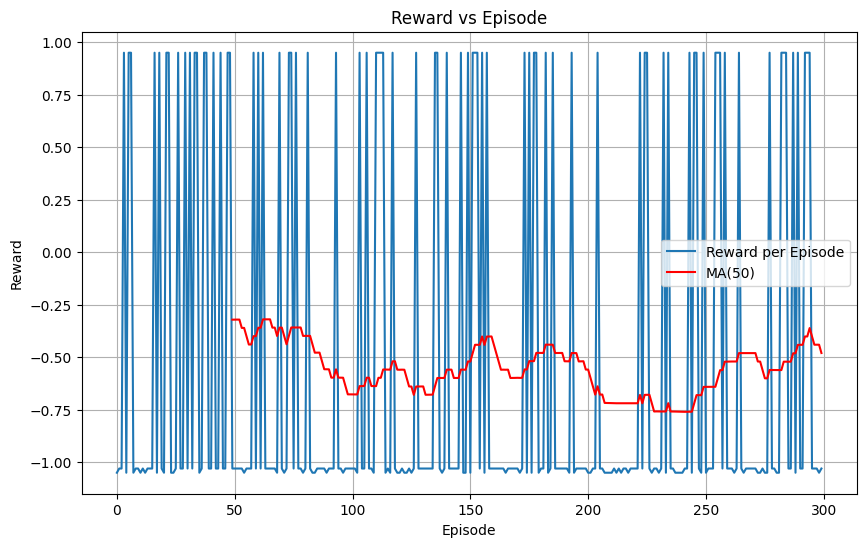

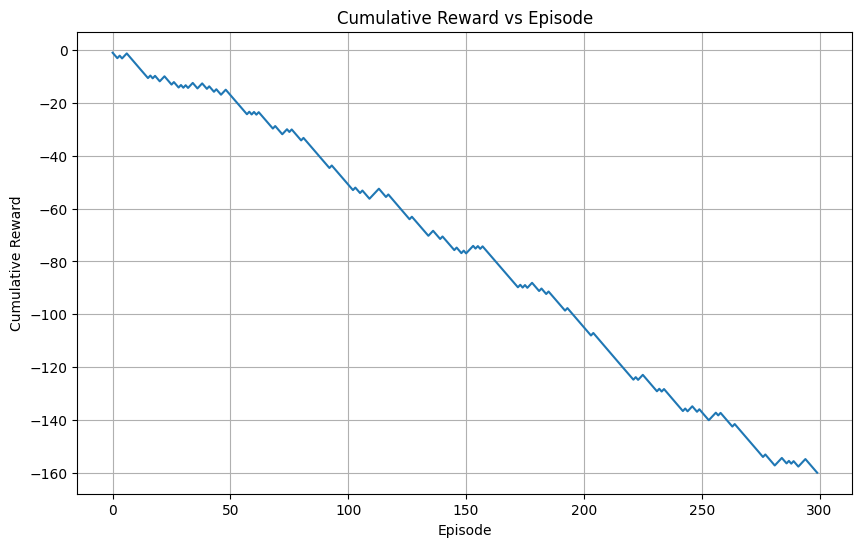

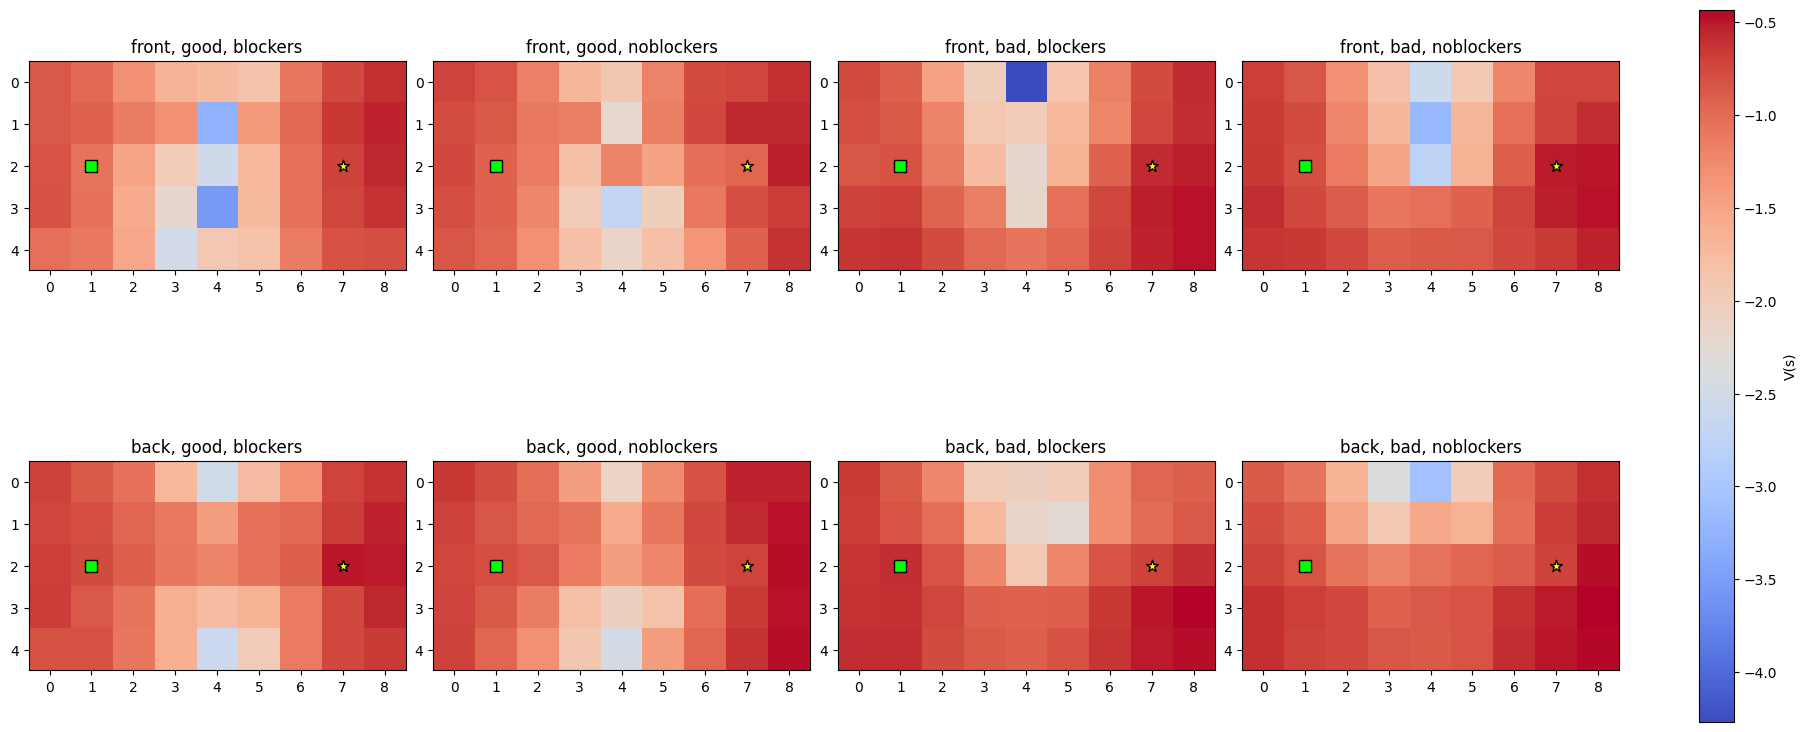

In [15]:
MCBaseApp('First-Visit Prediction', first_visit=True, control=False).run()


## Run App: Every-Visit Prediction

In [16]:
MCBaseApp('Every-Visit Prediction', first_visit=False, control=False).run()


Episode 100: avg reward (last 100) = -0.482
Episode 200: avg reward (last 100) = -0.620
Episode 300: avg reward (last 100) = -0.501


## Run App: First-Visit Control (unchanged)

Episode 100: avg reward (last 100) = -0.882
Episode 200: avg reward (last 100) = -0.787
Episode 300: avg reward (last 100) = -0.726


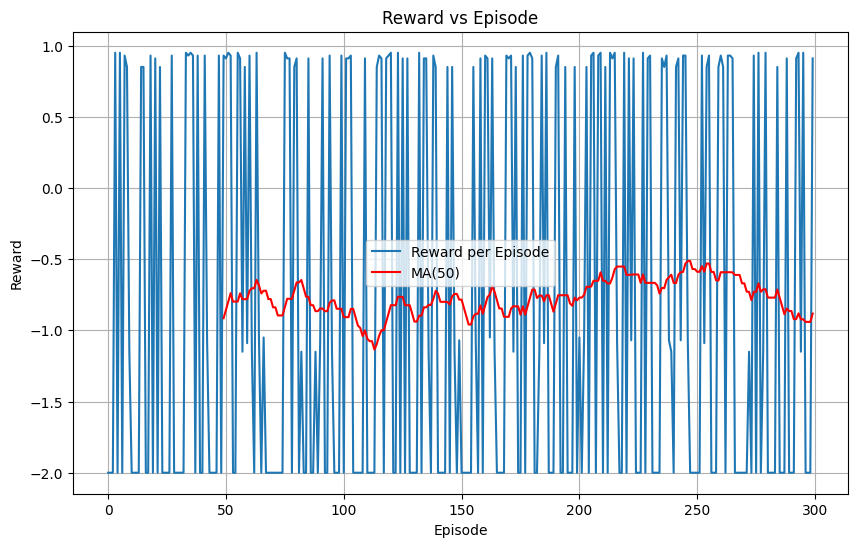

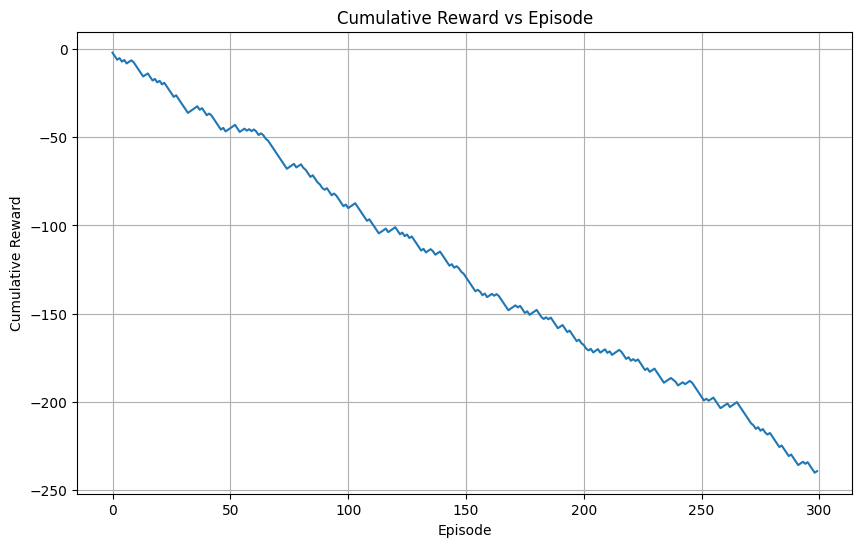

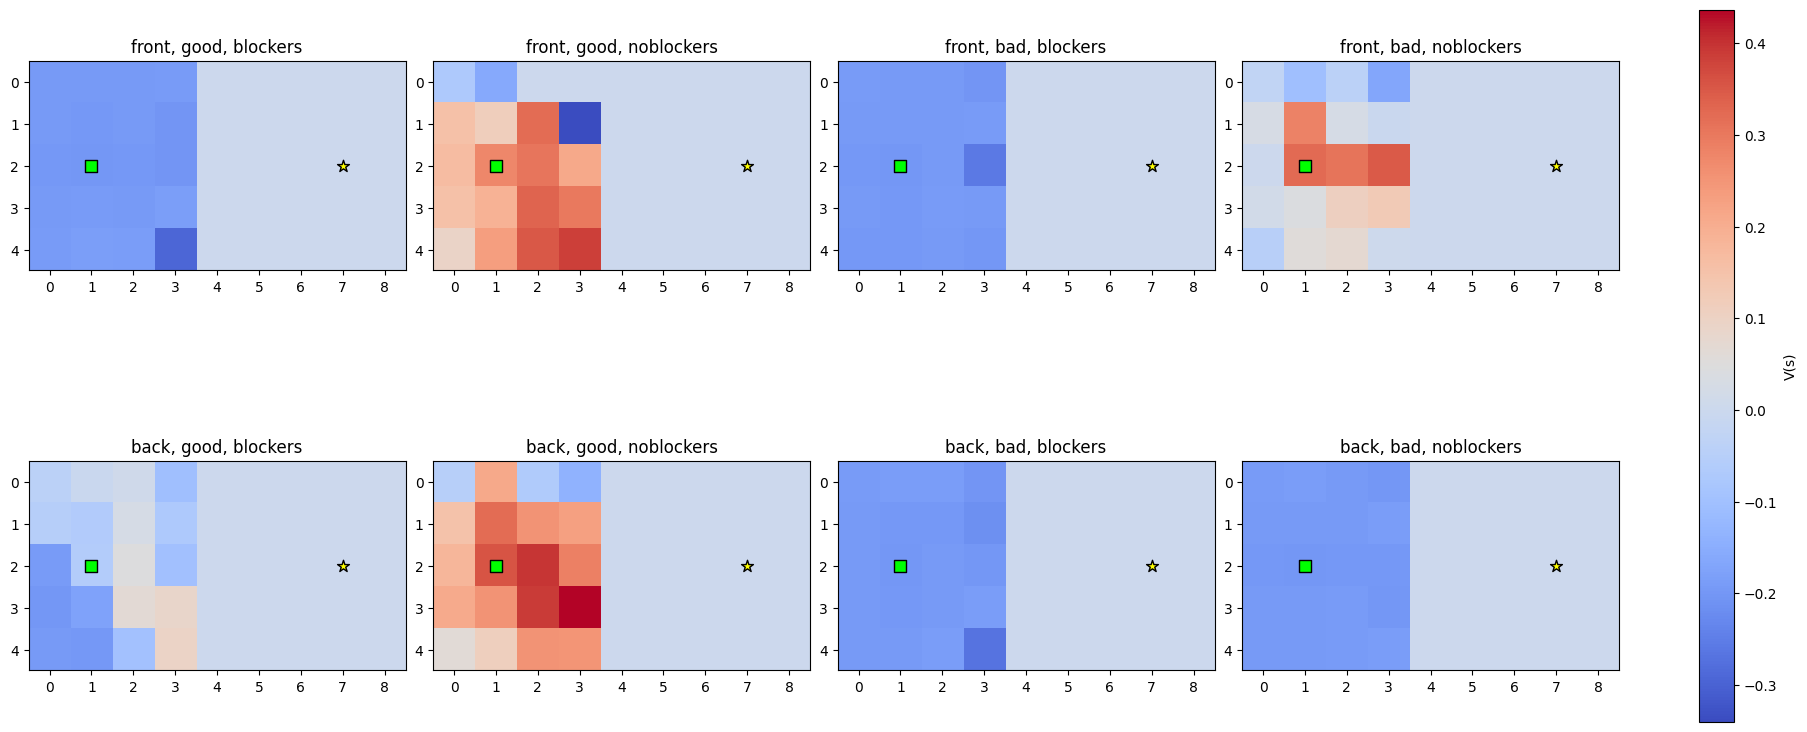

In [17]:
MCBaseApp('First-Visit Control', first_visit=True, control=True).run()


## Run App: Every-Visit Control

In [18]:
MCBaseApp('Every-Visit Control', first_visit=False, control=True).run()


Episode 100: avg reward (last 100) = -1.175
Episode 200: avg reward (last 100) = -1.405
Episode 300: avg reward (last 100) = -1.326
